In [1]:
import modern_robotics as mr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# LINK PARAMETERS -------------------------------------------------------------
L1 = 1.0
L2 = 1.0
m1 = 2.0
m2 = 2.0

# CENTER OF MASS --------------------------------------------------------------
p1 = np.array([L1/2, 0, 0])
p2 = np.array([L2/2, 0, 0])

# BASE LINK TRANSFORMATIONS ---------------------------------------------------
m01 = np.array([[1, 0, 0, 0],
                [0, 1, 0, 0],
                [0, 0, 1, 0],
                [0, 0, 0, 1]])

m12 = np.array([[1, 0, 0, 0],
                [0, 1, 0, 0],
                [0, 0, 1, 0],
                [0, 0, 0, 1]])

m23 = np.array([[1, 0, 0, 0],
                [0, 1, 0, 0],
                [0, 0, 1, -L2],
                [0, 0, 0, 1]])

m_list = np.array([m01, m12, m23])

# INERTIAL MATRICES -----------------------------------------------------------
g1 = np.zeros((6, 6))
g1[0:3, 0:3] = np.array([[0, 0, 0],
                         [0, 4, 0],
                         [0, 0, 4]])
g1[3:6, 3:6] = np.eye(3) * m1

g2 = np.zeros((6, 6))
g2[0:3, 0:3] = np.array([[4, 0, 0],
                         [0, 4, 0],
                         [0, 0, 0]])
g2[3:6, 3:6] = np.eye(3) * m2

g_list = np.array([g1, g2])

# SCREW AXES ------------------------------------------------------------------
s1 = np.array([0, 0, 1, 0, L1, 0])
s2 = np.array([1, 0, 0, 0, L2, 0])
s_list = np.array([s1, s2]).T

# JOINT STATES (POSITION, VELOCITY, ACCELERATIONS) ----------------------------
# position, velocity, and accelerations
thetalist = np.array([np.pi/4, np.pi/4])
dthetalist = np.array([0.0, 0.0])
ddthetalist = np.array([0.0, 0.0])

# gravity
g = np.array([0, 0, -10])

# no external forces on tip
Ftip = np.array([0, 0, 0, 0, 0, 0])


torques = mr.InverseDynamics(thetalist, dthetalist, ddthetalist, g, Ftip, m_list, g_list, s_list)
print(f"T1: {round(torques[0], 4)}")
print(f"T2: {round(torques[1], 4)}")

M = mr.MassMatrix(thetalist, m_list, g_list, s_list)
print(M)


T1: 0.0
T2: 14.1421
[[11.          1.41421356]
 [ 1.41421356  6.        ]]


[[11.          1.41421356]
 [ 1.41421356  6.        ]]


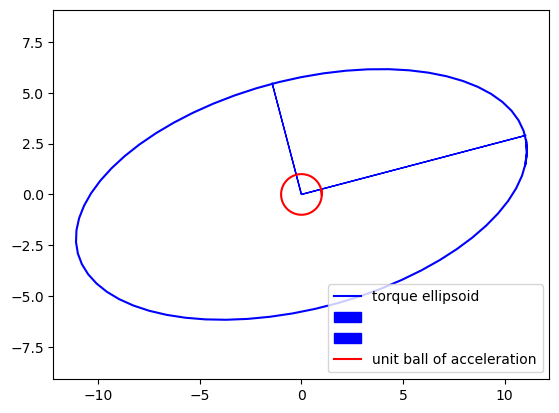

In [3]:
# DISPLAY ELLIPSOID (CODE ADAPTED FROM SLIDES) --------------------------------
M = mr.MassMatrix(thetalist, m_list, g_list, s_list)
print(M)

d, v = np.linalg.eig(M)
angle = np.arange(0, 2.1*np.pi, 0.1)
ang_accel = np.array([np.cos(angle), np.sin(angle)])
tau = M @ ang_accel
plt.plot(tau[0, :], tau[1, :], 'b')
plt.arrow(0, 0, d[0]*v[0, 0], d[0]*v[1, 0], head_width=0.05, head_length=0.05, fc='b', ec='b')
plt.arrow(0, 0, d[1]*v[0, 1], d[1]*v[1, 1], head_width=0.05, head_length=0.05, fc='b', ec='b')
plt.plot(ang_accel[0, :], ang_accel[1, :], 'r')
plt.axis('equal')
plt.legend(['torque ellipsoid', '', '', 'unit ball of acceleration'])
plt.show()